# Ch6 四種控制器(Four Types of Controllers)

**對應原書**:Chapter 6(P、PI、PID、PID+)
**軟體替代**:ModelQ 控制器方塊庫 → `DiscretePID` + 2-DOF 命令加權

## 學習目標
1. 在同一受控體上比較 **P / PI / PID / PID+(2-DOF 設定點加權)**。
2. 理解每多加一項換到什麼、付出什麼:
   - P:簡單、頻寬受限、有穩態誤差(對速度迴路的擾動)
   - PI:消除穩態誤差,代價是相位損失與 overshoot
   - PID:D 項加相位、允許更高增益,代價是雜訊放大
   - PID+:設定點加權(b<1)壓 overshoot,不犧牲擾動抑制

## 實驗設計
1 kHz 離散速度迴路;t=0 階躍命令、t=0.5 s 注入 -0.1 Nm 負載擾動。
比較指標:overshoot、命令響應、擾動最大跌落、恢復情況。

In [1]:
import sys, pathlib
sys.path.append(str(pathlib.Path('..').resolve()))
import numpy as np
import matplotlib.pyplot as plt
import control as ct
from common.control_helpers import (first_order, second_order, integrator, inertia,
                                    pi, pid, closed_loop, margins, step_metrics, bandwidth_hz)
from common.sim import (DiscretePID, MotorPlant, DCMotorPlant, TwoMassPlant,
                        Backlash, EncoderModel, Delay, saturate, quantize, coulomb)
from common.dsa import chirp_excitation, prbs_excitation, measure_frf, frf_of_system
from common.plots import bode_compare
np.set_printoptions(precision=4, suppress=True)

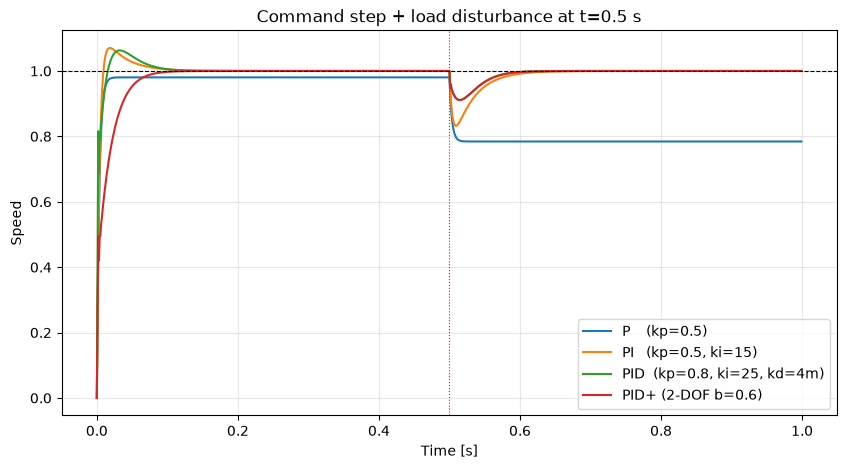

In [2]:
J, b = 0.002, 0.01
fs = 1000.0
dt = 1 / fs
n = int(1.0 / dt)
t = np.arange(n) * dt
dist = np.where(t >= 0.5, 0.1, 0.0)      # +0.1 Nm 負載轉矩(阻抗方向)

def run(kp, ki, kd, sp_weight=1.0, dfilt_hz=100.0):
    """2-DOF PID:P/D 作用在 sp_weight*r - y,I 作用在 r - y。"""
    plant = MotorPlant(J=J, b=b, dt=dt)
    pd_part = DiscretePID(kp=kp, ki=0.0, kd=kd, dt=dt, dfilt_hz=dfilt_hz)
    i_part = DiscretePID(kp=0.0, ki=ki, dt=dt)
    y = np.empty(n)
    for k in range(n):
        y[k] = plant.w
        u = pd_part.step(sp_weight * 1.0 - plant.w) + i_part.step(1.0 - plant.w)
        plant.step(u, t_dist=dist[k])
    return y

designs = {
    'P    (kp=0.5)':                dict(kp=0.5, ki=0.0, kd=0.0),
    'PI   (kp=0.5, ki=15)':         dict(kp=0.5, ki=15.0, kd=0.0),
    'PID  (kp=0.8, ki=25, kd=4m)':  dict(kp=0.8, ki=25.0, kd=0.004),
    'PID+ (2-DOF b=0.6)':           dict(kp=0.8, ki=25.0, kd=0.004, sp_weight=0.6),
}
results = {name: run(**kw) for name, kw in designs.items()}

plt.figure(figsize=(10, 5))
for name, y in results.items():
    plt.plot(t, y, label=name)
plt.axhline(1, color='k', ls='--', lw=0.8)
plt.axvline(0.5, color='r', ls=':', lw=0.8)
plt.xlabel('Time [s]'); plt.ylabel('Speed'); plt.legend(); plt.grid(alpha=0.3)
plt.title('Command step + load disturbance at t=0.5 s')
plt.show()

In [3]:
# 指標表
half = n // 2
print(f"{'controller':<28} {'OS%':>6} {'sse(cmd)':>9} {'dist dip':>9} {'sse(end)':>9}")
mtable = {}
for name, y in results.items():
    m1 = step_metrics(t[:half], y[:half])
    dip = float(1.0 - y[half:].min())
    sse_end = float(1.0 - y[-1])
    mtable[name] = dict(os=m1['overshoot_pct'], sse_cmd=m1['steady_state_error'],
                        dip=dip, sse_end=sse_end)
    print(f"{name:<28} {m1['overshoot_pct']:>6.1f} {m1['steady_state_error']:>9.4f} "
          f"{dip:>9.4f} {sse_end:>9.4f}")

controller                      OS%  sse(cmd)  dist dip  sse(end)
P    (kp=0.5)                   0.0    0.0196    0.2157    0.2157
PI   (kp=0.5, ki=15)            7.0   -0.0000    0.1676    0.0000
PID  (kp=0.8, ki=25, kd=4m)     6.3    0.0000    0.0889   -0.0000
PID+ (2-DOF b=0.6)              0.0   -0.0000    0.0889   -0.0000


## 頻域比較

D 項在中頻抬相位(這是它能換更高增益的原因),I 項在低頻抬增益(這是它消除穩態誤差的原因)。

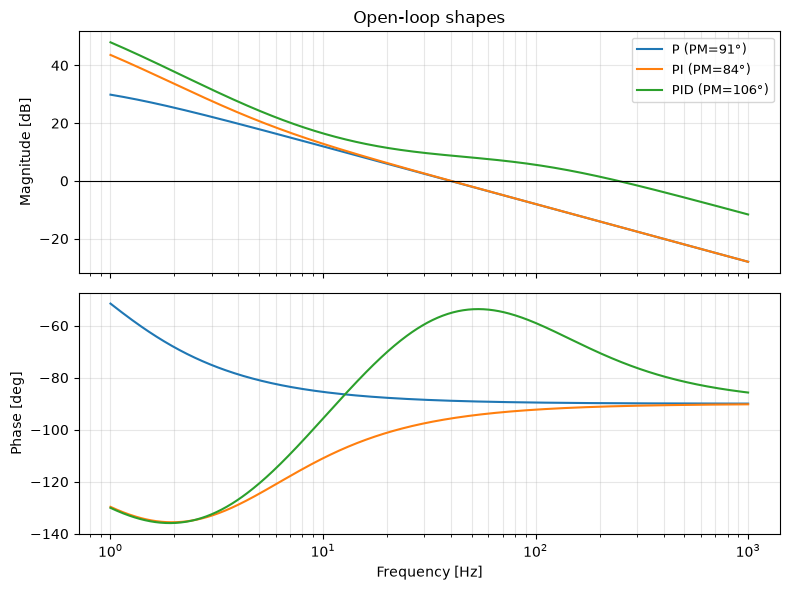

In [4]:
P_s = inertia(J=J, b=b)
ctrls = {
    'P':    pid(0.5),
    'PI':   pid(0.5, 15),
    'PID':  pid(0.8, 25, 0.004, n=2*np.pi*100),
}
items = [(f"{name} (PM={margins(C_*P_s)['pm_deg']:.0f}°)", C_ * P_s) for name, C_ in ctrls.items()]
fig, (axm, axp) = bode_compare(items, f_hz=np.logspace(0, 3, 500), title='Open-loop shapes')
axm.axhline(0, color='k', lw=0.8)
plt.show()

In [5]:
# ✅ 驗證
names = list(results)
mP, mPI, mPID, mPIDp = (mtable[k] for k in names)
assert mP['dip'] > 0.05 and abs(mP['sse_end']) > 0.05      # P:擾動留下穩態誤差
assert abs(mPI['sse_end']) < 0.005                          # PI:擾動誤差歸零
assert abs(mPID['sse_end']) < 0.005
assert mPID['dip'] < mPI['dip']                             # PID 擾動跌落較小(增益較高)
assert mPIDp['os'] < mPID['os'] - 2                         # 2-DOF 壓 overshoot
assert abs(mPIDp['dip'] - mPID['dip']) < 0.01               # 且不犧牲擾動抑制
print('Ch6 驗證通過 ✅')

Ch6 驗證通過 ✅


## 練習
1. 把 PID 的 `dfilt_hz` 從 100 降到 20,step response 與雜訊敏感度如何變化?
2. 在回授訊號加入 σ=0.01 的白雜訊,比較四種控制器的轉矩命令 RMS。
3. 試把 sp_weight 掃 0.4~1.0,畫 overshoot vs sp_weight 曲線。
4. 用第 3 章 zone-based 程序重新調 PID 的三個增益,能比表中設計更好嗎?